# 01 — ACLED Preprocessing

This notebook preprocesses raw ACLED event-level data into a **country-week panel** ready for both the baseline and extended regression models.

| | |
|---|---|
| Countries | Mali, Niger, Nigeria, Burkina Faso, Ghana |
| Time frame | 2015-01-01 to 2023-12-31 |
| Unit of analysis | Country-week |
| Output | `processed/acled_country_week.csv` |

---

## Pipeline

1. Load raw ACLED Excel export
2. Standardise column names and parse dates
3. Filter to target countries and date range
4. Filter to Political Violence events only
5. Aggregate to country-week level (snap dates to Monday)
6. Build a complete country-week skeleton to fill peaceful weeks with zero
7. Engineer features: lags, moving averages, volatility, persistence
8. Add outcome variables (event counts h weeks ahead)
9. Diagnostics and export

## Why snap dates to Monday?

ACLED records the start of the ISO week, which is always a Monday. The GDELT export uses the same convention. Snapping both datasets to the Monday of each ISO week before merging ensures the two panels align on a common time index, avoiding off-by-one mismatches that would fill the merged panel with zeros.

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
# Paths relative to repo root
REPO_ROOT = Path().resolve().parent  # one level up from notebooks/

RAW_DIR   = REPO_ROOT / "raw_data"
PROC_DIR  = REPO_ROOT / "processed"

RAW_FILE = RAW_DIR / "Africa_aggregated_data_up_to_week_of-2026-03-21.xlsx"
PROC_DIR.mkdir(parents=True, exist_ok=True)

# ── Study parameters ───────────────────────────────────────────────────────────
TARGET_COUNTRIES = ["Mali", "Niger", "Nigeria", "Burkina Faso", "Ghana"]
START_DATE       = "2015-01-01"
END_DATE         = "2023-12-31"
HORIZONS         = [1, 2, 4]   # forecast horizons in weeks

# ACLED DISORDER_TYPE value used to identify political violence events.
# We restrict to this category to exclude demonstrations, strategic
# developments, etc. that are not the focus of the research question.
DISORDER_TYPE = "Political violence"

print(f"Raw file: {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")
print(f"Output dir:  {PROC_DIR}")

Raw file: C:\Users\faiza\Documents\Uni\Year 3\Thesis\Data Preprocessing\raw_data\Africa_aggregated_data_up_to_week_of-2026-03-21.xlsx
File exists: True
Output dir:  C:\Users\faiza\Documents\Uni\Year 3\Thesis\Data Preprocessing\processed


## 1. Load Raw ACLED Data

In [2]:
# ACLED provides a weekly aggregated Excel export.
# The WEEK column contains the Monday start date of each ISO week.
df_raw = pd.read_excel(
    RAW_FILE,
    sheet_name="Sheet1",
    engine="openpyxl",
)

# Standardise column names
df_raw.columns = df_raw.columns.str.strip().str.upper()

print(f"Raw shape: {df_raw.shape}")
print("Columns:", df_raw.columns.tolist())
df_raw.head(3)

Raw shape: (268511, 13)
Columns: ['WEEK', 'REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'DISORDER_TYPE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE']


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2004-10-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,2,NaN,Political violence,47.0,26.4839,-1.388
1,2005-04-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,0,NaN,Political violence,47.0,26.4839,-1.388
2,2005-06-25,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,14,NaN,Political violence,47.0,26.4839,-1.388


## 2. Parse Dates

The WEEK column is parsed as a date. ACLED exports can use Dutch month names in some locale settings (e.g. '03-januari-2015'), so a Dutch-to-English mapping is applied before parsing.

In [3]:
DUTCH_MONTHS = {
    "januari": "January",  "februari": "February", "maart": "March",
    "april": "April",      "mei": "May",            "juni": "June",
    "juli": "July",        "augustus": "August",    "september": "September",
    "oktober": "October",  "november": "November",  "december": "December",
}

def fix_dutch_date(s):
    if not isinstance(s, str):
        return s
    for nl, en in DUTCH_MONTHS.items():
        s = s.replace(nl, en)
    return s

df_raw["WEEK"] = df_raw["WEEK"].astype(str).apply(fix_dutch_date)
df_raw["WEEK_DATE"] = pd.to_datetime(df_raw["WEEK"], dayfirst=True, errors="coerce")

bad_dates = df_raw["WEEK_DATE"].isna().sum()
print(f"Unparseable dates: {bad_dates}")
if bad_dates > 0:
    print(df_raw.loc[df_raw["WEEK_DATE"].isna(), "WEEK"].unique()[:10])

Unparseable dates: 0


C:\Users\faiza\AppData\Local\Temp\ipykernel_34252\281312554.py:16: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_raw["WEEK_DATE"] = pd.to_datetime(df_raw["WEEK"], dayfirst=True, errors="coerce")


## 3. Filter: Countries and Date Range

In [4]:
df = df_raw.dropna(subset=["WEEK_DATE"]).copy()
df["COUNTRY"] = df["COUNTRY"].str.strip()

df = df[
    df["COUNTRY"].isin(TARGET_COUNTRIES) &
    (df["WEEK_DATE"] >= pd.Timestamp(START_DATE)) &
    (df["WEEK_DATE"] <= pd.Timestamp(END_DATE))
].copy()

print(f"After country + date filter: {df.shape}")
print(df["COUNTRY"].value_counts())

After country + date filter: (33061, 14)
COUNTRY
Nigeria         17755
Mali             5713
Burkina Faso     5687
Niger            2288
Ghana            1618
Name: count, dtype: int64


## 4. Filter: Political Violence Only

ACLED classifies events into disorder types: Political Violence, Demonstrations, and Strategic Developments. The research question concerns political violence — armed conflict, attacks, explosions — so we restrict to rows where `DISORDER_TYPE == 'Political violence'`. Demonstrations (protests, riots) and strategic developments (non-violent military activity) are excluded.

In [5]:
print("All disorder types in data:", df["DISORDER_TYPE"].unique())

df_violence = df[df["DISORDER_TYPE"] == DISORDER_TYPE].copy()
print(f"After political violence filter: {df_violence.shape}")
print("Disorder types remaining:", df_violence["DISORDER_TYPE"].unique())

All disorder types in data: ['Political violence' 'Demonstrations' 'Strategic developments'
 'Political violence; Demonstrations']
After political violence filter: (21726, 14)
Disorder types remaining: ['Political violence']


## 5. Aggregate to Country-Week Level

Each row in the raw ACLED export is one event type in one admin region in one week. We aggregate to the country-week level by summing events and fatalities across all regions and event sub-types within each country-week.

Before aggregating, we snap each date to the Monday of its ISO week. This ensures ACLED and GDELT use the same week index, which is critical for the merge in notebook 03.

In [6]:
for col in ["EVENTS", "FATALITIES"]:
    if col in df_violence.columns:
        df_violence[col] = pd.to_numeric(df_violence[col], errors="coerce").fillna(0)

# Snap to Monday of the ISO week
df_violence["week_start"] = df_violence["WEEK_DATE"].apply(
    lambda dt: dt - pd.Timedelta(days=dt.weekday())
)
assert (df_violence["week_start"].dt.weekday == 0).all(), "Non-Monday dates found"

agg = (
    df_violence
    .groupby(["COUNTRY", "week_start"])
    .agg(
        n_events     = ("EVENTS",     "sum"),
        n_fatalities = ("FATALITIES", "sum"),
    )
    .reset_index()
)

print(f"Aggregated shape: {agg.shape}")
print("Sample week_start values:", sorted(agg["week_start"].unique())[:5])

Aggregated shape: (2035, 4)
Sample week_start values: [Timestamp('2014-12-29 00:00:00'), Timestamp('2015-01-05 00:00:00'), Timestamp('2015-01-12 00:00:00'), Timestamp('2015-01-19 00:00:00'), Timestamp('2015-01-26 00:00:00')]


## 6. Build Complete Country-Week Skeleton

ACLED only records rows when events occur. Weeks with no political violence have no row. If we leave gaps, the lagged features computed in the next step will skip over peaceful weeks and produce incorrect values.

We create a complete grid of all country × week combinations and left-merge the aggregated data onto it, filling missing weeks with zero. This ensures every country has a continuous weekly time series with no gaps, and that peaceful weeks are explicitly represented as n_events = 0.

In [7]:
all_weeks = pd.date_range(start=START_DATE, end=END_DATE, freq="W-MON")

print("First 5 skeleton weeks:", all_weeks[:5].tolist())
print("First 5 ACLED agg weeks:", sorted(agg["week_start"].unique())[:5])
# These should match — if not, the Monday snap above did not work correctly

skeleton = pd.MultiIndex.from_product(
    [TARGET_COUNTRIES, all_weeks],
    names=["COUNTRY", "week_start"]
).to_frame(index=False)

panel = skeleton.merge(agg, on=["COUNTRY", "week_start"], how="left")
panel[["n_events", "n_fatalities"]] = panel[["n_events", "n_fatalities"]].fillna(0)
panel = panel.sort_values(["COUNTRY", "week_start"]).reset_index(drop=True)

# Diagnostic: totals must match between agg and panel
print(f"\nTotal events in agg:   {agg['n_events'].sum():.0f}")
print(f"Total events in panel: {panel['n_events'].sum():.0f}")
print("(Small difference is expected if a handful of agg weeks fall outside the skeleton range)")
print(f"\nPanel shape: {panel.shape}")
print(f"Expected: {len(TARGET_COUNTRIES)} countries × {len(all_weeks)} weeks = {len(TARGET_COUNTRIES)*len(all_weeks)} rows")

First 5 skeleton weeks: [Timestamp('2015-01-05 00:00:00'), Timestamp('2015-01-12 00:00:00'), Timestamp('2015-01-19 00:00:00'), Timestamp('2015-01-26 00:00:00'), Timestamp('2015-02-02 00:00:00')]
First 5 ACLED agg weeks: [Timestamp('2014-12-29 00:00:00'), Timestamp('2015-01-05 00:00:00'), Timestamp('2015-01-12 00:00:00'), Timestamp('2015-01-19 00:00:00'), Timestamp('2015-01-26 00:00:00')]

Total events in agg:   35888
Total events in panel: 35862
(Small difference is expected if a handful of agg weeks fall outside the skeleton range)

Panel shape: (2345, 4)
Expected: 5 countries × 469 weeks = 2345 rows


## 7. Feature Engineering

All features are constructed within each country group independently. Using `.shift()` ensures only past information enters each feature — no future data leaks into the predictors.

The features cover four conceptual dimensions:

| Feature group | Variables | What it captures |
|---|---|---|
| Short-term lags | `events_lag1–4` | Event count 1–4 weeks ago |
| Fatality lags | `fatalities_lag1–2` | Recent severity of violence |
| Moving averages | `events_ma4/8/12` | Sustained conflict level over 4, 8, 12 weeks |
| Volatility | `events_std4/8` | How erratic recent conflict has been |
| Trend | `events_delta4` | Whether violence is rising or falling |
| Binary lags | `conflict_lag1/2` | Was there any conflict 1 or 2 weeks ago? |
| Persistence | `conflict_weeks_last4/8` | How many recent weeks had any conflict |

Not all of these will enter the final model — the model notebooks select a non-collinear subset. All are computed here so the merged panel is complete.

In [8]:
def engineer_acled_features(grp):
    """Compute all ACLED-derived features for one country group."""
    g = grp.copy().sort_values("week_start")

    # Individual lags (event counts)
    g["events_lag1"] = g["n_events"].shift(1)
    g["events_lag2"] = g["n_events"].shift(2)
    g["events_lag3"] = g["n_events"].shift(3)
    g["events_lag4"] = g["n_events"].shift(4)

    # Fatality lags
    g["fatalities_lag1"] = g["n_fatalities"].shift(1)
    g["fatalities_lag2"] = g["n_fatalities"].shift(2)

    # Moving averages — shift(1) ensures only past data enters each average
    g["events_ma4"]  = g["n_events"].shift(1).rolling(4,  min_periods=1).mean()
    g["events_ma8"]  = g["n_events"].shift(1).rolling(8,  min_periods=1).mean()
    g["events_ma12"] = g["n_events"].shift(1).rolling(12, min_periods=1).mean()

    # Volatility (rolling standard deviation)
    g["events_std4"] = g["n_events"].shift(1).rolling(4, min_periods=2).std()
    g["events_std8"] = g["n_events"].shift(1).rolling(8, min_periods=2).std()

    # Trend: change from 4 weeks ago to last week
    g["events_delta4"] = g["n_events"].shift(1) - g["n_events"].shift(5)

    # Binary conflict indicators
    g["conflict_lag1"] = (g["n_events"].shift(1) > 0).astype(int)
    g["conflict_lag2"] = (g["n_events"].shift(2) > 0).astype(int)

    # Persistence: count of weeks with any conflict in past N weeks
    conflict_binary = (g["n_events"] > 0).astype(float)
    g["conflict_weeks_last4"] = conflict_binary.shift(1).rolling(4, min_periods=1).sum()
    g["conflict_weeks_last8"] = conflict_binary.shift(1).rolling(8, min_periods=1).sum()

    return g


panel = (
    panel
    .groupby("COUNTRY", group_keys=False)
    .apply(engineer_acled_features)
    .reset_index(drop=True)
)

print(f"After feature engineering: {panel.shape}")
print("New columns:", [c for c in panel.columns if c not in ["COUNTRY", "week_start", "n_events", "n_fatalities"]])

After feature engineering: (2345, 20)
New columns: ['events_lag1', 'events_lag2', 'events_lag3', 'events_lag4', 'fatalities_lag1', 'fatalities_lag2', 'events_ma4', 'events_ma8', 'events_ma12', 'events_std4', 'events_std8', 'events_delta4', 'conflict_lag1', 'conflict_lag2', 'conflict_weeks_last4', 'conflict_weeks_last8']


C:\Users\faiza\AppData\Local\Temp\ipykernel_34252\3998584266.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(engineer_acled_features)


## 8. Add Outcome Variables

For each forecast horizon h ∈ {1, 2, 4} weeks, we create:

- `events_h{h}`: count of political violence events h weeks ahead — the model's prediction target
- `conflict_h{h}`: binary indicator (any conflict or not) — kept for reference

These are created using `.shift(-h)` within each country group, so the last h rows per country have NaN outcomes. These rows are dropped in the model notebooks before fitting.

In [9]:
def add_outcome_variables(grp, horizons):
    """Add count and binary outcome variables for each forecast horizon."""
    g = grp.copy().sort_values("week_start")
    for h in horizons:
        # Count outcome — what the negative binomial model predicts
        g[f"events_h{h}"]   = g["n_events"].shift(-h).astype("Int64")
        # Binary outcome — kept for reference and summary statistics
        g[f"conflict_h{h}"] = (g["n_events"].shift(-h) > 0).astype("Int8")
    return g


panel = (
    panel
    .groupby("COUNTRY", group_keys=False)
    .apply(lambda g: add_outcome_variables(g, HORIZONS))
    .reset_index(drop=True)
)

print("Outcome variable summary:")
for h in HORIZONS:
    col   = f"events_h{h}"
    valid = panel[col].dropna()
    print(f"  events_h{h}: mean={valid.mean():.2f}, median={valid.median():.0f}, "
          f"max={valid.max():.0f}, zero weeks={100*(valid==0).mean():.1f}%")

Outcome variable summary:
  events_h1: mean=15.31, median=8, max=102, zero weeks=13.2%
  events_h2: mean=15.34, median=8, max=102, zero weeks=13.1%
  events_h4: mean=15.37, median=8, max=102, zero weeks=13.1%


C:\Users\faiza\AppData\Local\Temp\ipykernel_34252\1947197542.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_outcome_variables(g, HORIZONS))


## 9. Fill NaN Values and Final Checks

Feature columns have NaN values in the first few rows of each country's series because the lag and rolling calculations need warm-up periods. These are filled with zero — a reasonable assumption since the country had no recorded conflict history before the series starts.

Outcome columns are **not** filled — NaN there correctly signals that no future data is available for those rows.

In [10]:
feature_cols = [
    c for c in panel.columns
    if c not in ["COUNTRY", "week_start", "n_events", "n_fatalities"]
    and not c.startswith("events_h")
    and not c.startswith("conflict_h")
]

panel[feature_cols] = panel[feature_cols].fillna(0)

na_check = panel[feature_cols].isna().sum()
print("NaN in feature columns:")
print(na_check[na_check > 0] if na_check.any() else "  None ✓")

NaN in feature columns:
  None ✓


In [11]:
print(f"Final panel shape: {panel.shape}")
print(f"Countries: {sorted(panel['COUNTRY'].unique())}")
print(f"Date range: {panel['week_start'].min().date()} → {panel['week_start'].max().date()}")
print(f"Weeks per country: {panel.groupby('COUNTRY')['week_start'].count().to_dict()}")
print(f"\nTotal n_events: {panel['n_events'].sum():.0f}")
print(f"Conflict rate (h=1): {panel['conflict_h1'].mean()*100:.1f}% of country-weeks")

print("\nMean events per week by country:")
print(
    panel.dropna(subset=["events_h1"])
    .groupby("COUNTRY")["events_h1"]
    .agg(["mean", "median", "max", lambda x: round((x==0).mean()*100, 1)])
    .rename(columns={"<lambda_0>": "pct_zero"})
    .round(2)
)

Final panel shape: (2345, 26)
Countries: ['Burkina Faso', 'Ghana', 'Mali', 'Niger', 'Nigeria']
Date range: 2015-01-05 → 2023-12-25
Weeks per country: {'Burkina Faso': 469, 'Ghana': 469, 'Mali': 469, 'Niger': 469, 'Nigeria': 469}

Total n_events: 35862
Conflict rate (h=1): 86.6% of country-weeks

Mean events per week by country:
               mean  median  max  pct_zero
COUNTRY                                   
Burkina Faso  13.69    10.0   63      17.5
Ghana          2.02     1.0   11      27.8
Mali          14.74    13.0   52       2.4
Niger          4.97     4.0   23      18.6
Nigeria       41.13    34.0  102       0.0


## 10. Export

In [12]:
OUT_PATH = PROC_DIR / "acled_country_week.csv"
panel.to_csv(OUT_PATH, index=False)
print(f"Saved → {OUT_PATH}")
print(f"Shape: {panel.shape}")
print(f"Columns: {panel.columns.tolist()}")

Saved → C:\Users\faiza\Documents\Uni\Year 3\Thesis\Data Preprocessing\processed\acled_country_week.csv
Shape: (2345, 26)
Columns: ['COUNTRY', 'week_start', 'n_events', 'n_fatalities', 'events_lag1', 'events_lag2', 'events_lag3', 'events_lag4', 'fatalities_lag1', 'fatalities_lag2', 'events_ma4', 'events_ma8', 'events_ma12', 'events_std4', 'events_std8', 'events_delta4', 'conflict_lag1', 'conflict_lag2', 'conflict_weeks_last4', 'conflict_weeks_last8', 'events_h1', 'conflict_h1', 'events_h2', 'conflict_h2', 'events_h4', 'conflict_h4']


## 11. Descriptive Plot

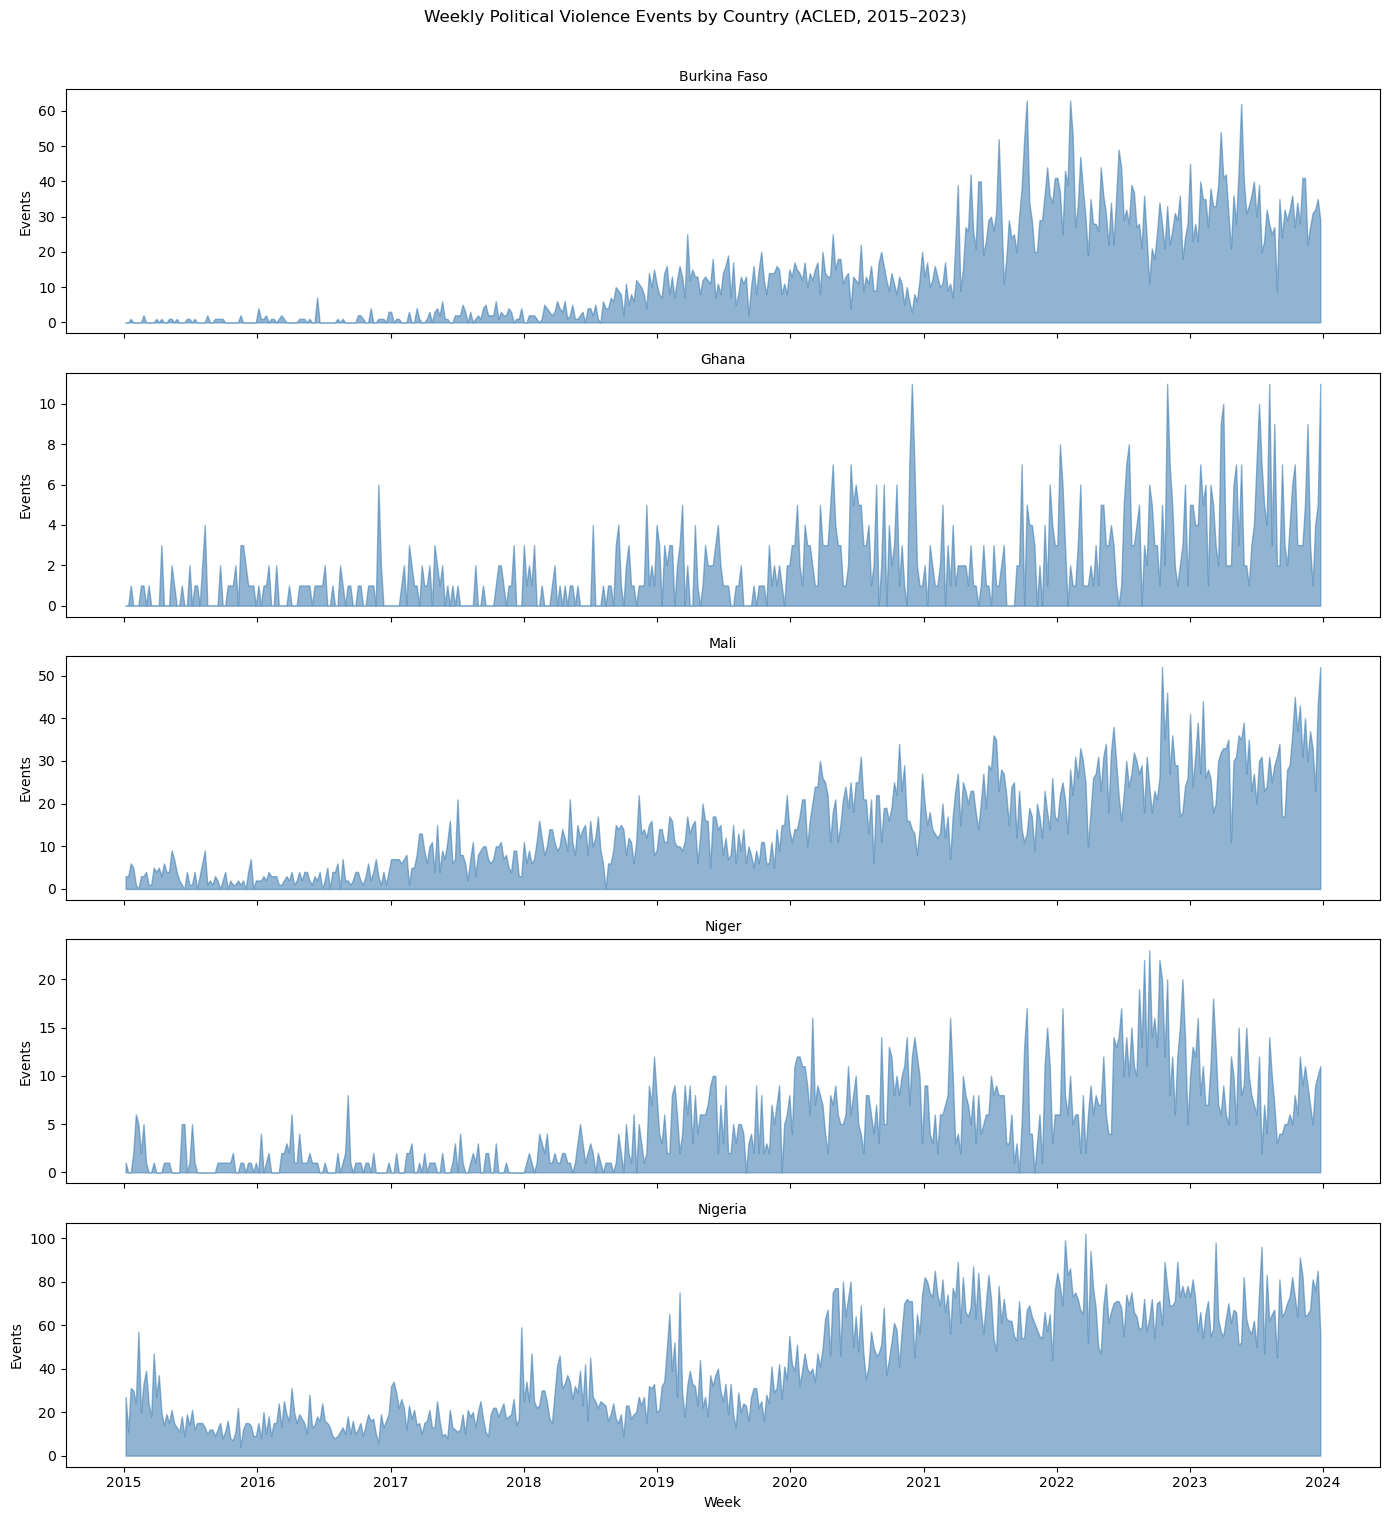

In [13]:
fig, axes = plt.subplots(len(TARGET_COUNTRIES), 1,
                          figsize=(14, 3 * len(TARGET_COUNTRIES)), sharex=True)

for ax, country in zip(axes, sorted(TARGET_COUNTRIES)):
    sub = panel[panel["COUNTRY"] == country]
    ax.fill_between(sub["week_start"], sub["n_events"], alpha=0.6, color="steelblue")
    ax.set_title(country, fontsize=10)
    ax.set_ylabel("Events")

axes[-1].set_xlabel("Week")
plt.suptitle("Weekly Political Violence Events by Country (ACLED, 2015–2023)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROC_DIR / "acled_violence_timeline.png", dpi=120, bbox_inches="tight")
plt.show()